# Task 4.1 — Single Strain HAI H1N1 A/Victoria/4897/2022 (D28)

**4.1 predict magnitude of antibody response — H1N1 A/Victoria/4897/2022 (D28)**
* Training Data: Demographics + Day 0 + Day 7 innate
* Assay: HAI / Measure: Single strain titer / Metric: Spearman correlation
* Full description: HAI titer for H1N1 A/Victoria/4897/2022 at Day 28

---

## Design notes

**y-values:** log2-transformed. Since Spearman only cares about ranking, no inverse transform is needed for evaluation. Metrics (RMSE, MAE, Spearman) are all in log2 space; CSVs use `np.exp2` to output raw titer scale values.

**Spearman correlation:** ranks predictions and truth; rewards monotonic agreement regardless of scale. Robust to outliers. Score: 1.0 = perfect, 0.0 = no signal, -1.0 = reversed.

**5-fold cross-validation:** each participant's prediction is made by a model that never saw them during training.

In [45]:
STRAIN = 'H1N1 A/Victoria/4897/2022'
TARGET_COL = f'HAI_{STRAIN}_d28'
AUTOML_MAX_MODELS = 10
AUTOML_SEED = 1
AUTO_ML_MAX_RUNTIME_SECONDS = 60 * 1
ONLY_TRANSCRIPTOMICS_PARTICIPANTS = False  # only train on participants with transcriptomics data (warning: small subset)
FORCE_KEEP_TRANSCRIPTOMICS = True  # even if high missing-ness, keep the transcriptomics cols for training
MISSING_THRESHOLD = 0.8  # drop features if missing more than this % of data

In [46]:
CSV_PATH = '../cleaned_data/train_combined.csv'
CHALLENGE_DATA_PATH = '../cleaned_data'
SUBMISSION_PATH = 'submission'

In [47]:
import io
import warnings
from contextlib import redirect_stderr, redirect_stdout

import h2o
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from h2o.automl import H2OAutoML
from scipy.stats import spearmanr

In [48]:
challenge_data = pd.read_csv(CHALLENGE_DATA_PATH + '/challenge_combined.csv')
print(f'Challenge shape: {challenge_data.shape}')

Challenge shape: (40, 311)


---
## Preprocessing

### Preprocessing — target coverage

Only participants with a measured `HAI_H1N1 A/Victoria/4897/2022_d28` are usable as training rows.
This strain appears only in specific cohort years so coverage is substantially less than the full
3 757-participant dataset.

In [49]:
df = pd.read_csv(CSV_PATH)
print(f'Pre-filtered shape: {df.shape}')

Pre-filtered shape: (3757, 489)


In [50]:
df = df[df[TARGET_COL].notna()].reset_index(drop=True)
print(f'Filtered shape: {df.shape}')

Filtered shape: (212, 489)


In [51]:
all_null_cols = df.columns[df.isna().all()].tolist()
df = df.drop(columns=all_null_cols)
print(f'Dropped {len(all_null_cols)} all-null columns. New shape: {df.shape}')

Dropped 455 all-null columns. New shape: (212, 34)


### Coerce HAI string columns to numeric

Some `HAI_*` titer columns are stored as strings (e.g. censored values like `<10` or stringified NaN).
H2O treats those as categorical at training time but numeric at prediction time, which crashes `predict()`.
We coerce all `HAI_*` string columns to numeric (non-numeric values become NaN). Genuine categoricals
(demographics) are left alone.

In [52]:
# str_cols = df.select_dtypes(include=['object', 'str']).columns.tolist()
# print(f'String columns ({len(str_cols)}):', str_cols)

# for c in str_cols:
#     print(f'  {c}: sample={df[c].dropna().unique()[:5].tolist()}')

# hai_str_cols = [c for c in str_cols if c.startswith('HAI_')]
# for c in hai_str_cols:
#     df[c] = pd.to_numeric(df[c], errors='coerce')
# print(f'\nCoerced {len(hai_str_cols)} HAI string columns to numeric.')
# print(f'Remaining string columns: {df.select_dtypes(include=["object", "str"]).columns.tolist()}')

# # Apply same coercion to challenge data so type mismatch can't crash predict()
# challenge_hai_str_cols = [c for c in challenge_data.select_dtypes(include=['object', 'str']).columns
#                           if c.startswith('HAI_')]
# for c in challenge_hai_str_cols:
#     challenge_data[c] = pd.to_numeric(challenge_data[c], errors='coerce')
# print(f'Coerced {len(challenge_hai_str_cols)} HAI string columns in challenge data.')

In [53]:
h3n2_d0 = [c for c in df.columns if 'H3N2' in c and c.endswith('_d0')]
h1n1_d0 = [c for c in df.columns if 'H1N1' in c and c.endswith('_d0')]
all_d0 = [c for c in df.columns if c.startswith('HAI_') and c.endswith('_d0')]

df['HAI_mean_H3N2_d0'] = df[h3n2_d0].mean(axis=1)
df['HAI_mean_H1N1_d0'] = df[h1n1_d0].mean(axis=1)
df['HAI_mean_all_d0'] = df[all_d0].mean(axis=1)
df['HAI_n_measured_d0'] = df[all_d0].notna().sum(axis=1)
print(f'Added 4 HAI aggregate features. Shape: {df.shape}')

ch_h3n2_d0 = [c for c in challenge_data.columns if 'H3N2' in c and c.endswith('_d0')]
ch_h1n1_d0 = [c for c in challenge_data.columns if 'H1N1' in c and c.endswith('_d0')]
ch_all_d0 = [c for c in challenge_data.columns if c.startswith('HAI_') and c.endswith('_d0')]

challenge_data['HAI_mean_H3N2_d0'] = challenge_data[ch_h3n2_d0].mean(axis=1)
challenge_data['HAI_mean_H1N1_d0'] = challenge_data[ch_h1n1_d0].mean(axis=1)
challenge_data['HAI_mean_all_d0'] = challenge_data[ch_all_d0].mean(axis=1)
challenge_data['HAI_n_measured_d0'] = challenge_data[ch_all_d0].notna().sum(axis=1)
print(f'Challenge shape after aggregates: {challenge_data.shape}')

Added 4 HAI aggregate features. Shape: (212, 38)
Challenge shape after aggregates: (40, 315)


### Drop constant features

Any column with only one unique value (numeric or categorical) carries no signal. Since we filtered
to participants with this specific target, some categorical features that vary across the full dataset
(e.g. `PART_race`, `PART_geolocation`) may collapse to a single value here.

In [54]:
constant_cols = [c for c in df.columns
                 if c != TARGET_COL and df[c].nunique(dropna=True) <= 1]
df = df.drop(columns=constant_cols)
print(f'Dropped {len(constant_cols)} constant columns: {constant_cols}')
print(f'Shape: {df.shape}')

Dropped 1 constant columns: ['HAI_n_measured_d0']
Shape: (212, 37)


### Transcriptomics stats

In [55]:
tran_cols = [c for c in df.columns if c.startswith('TRAN_')]
df_tran = df[df[tran_cols].notna().any(axis=1)].reset_index(drop=True)
print(f'Participants with TRAN data: {df_tran.shape[0]} / {df.shape[0]} '
      f'({df_tran.shape[0] / df.shape[0]:.1%})')

if ONLY_TRANSCRIPTOMICS_PARTICIPANTS:
    df = df_tran
    print(f'Filtered df to TRAN-only participants. Shape: {df.shape}')

Participants with TRAN data: 0 / 212 (0.0%)


In [56]:
# num_to_show = 15
# tran_corrs = df_tran[tran_cols + [TARGET_COL]].corr()[TARGET_COL].drop(TARGET_COL)
# top = tran_corrs.loc[tran_corrs.abs().sort_values(ascending=False).head(num_to_show).index]
# top = top.sort_values()

# vmax = top.abs().max()
# colors = plt.cm.coolwarm((top.values / vmax + 1) / 2)

# fig, ax = plt.subplots(figsize=(7, max(4, num_to_show * 0.3)))
# ax.barh(top.index, top.values, color=colors, edgecolor='black', linewidth=0.3)
# ax.axvline(0, color='black', linewidth=0.8)
# ax.set_xlabel(f'Pearson r with {TARGET_COL}')
# ax.set_title(f'Top {num_to_show}/{len(tran_cols)} Transcriptomics PCs by correlation with target')
# ax.set_xlim(-vmax * 1.15, vmax * 1.15)
# plt.tight_layout()
# plt.show()

### Drop sparse features

Drop columns missing in more than `MISSING_THRESHOLD` of rows — they're too gappy for models to
learn from and they slow training enough that tree models time out.

In [57]:
miss_frac = df.isna().mean()
sparse_cols = miss_frac[miss_frac > MISSING_THRESHOLD].index

if FORCE_KEEP_TRANSCRIPTOMICS:
    cols_to_drop = [c for c in sparse_cols if c != TARGET_COL and c not in tran_cols]
else:
    cols_to_drop = [c for c in sparse_cols if c != TARGET_COL]

df = df.drop(columns=cols_to_drop)
print(f'Dropped {len(cols_to_drop)} columns with >{MISSING_THRESHOLD:.0%} missing.')
print(f'Shape: {df.shape}')

Dropped 0 columns with >80% missing.
Shape: (212, 37)


In [58]:
surviving_tran = [c for c in df.columns if c.startswith('TRAN_')]
print(f'TRAN columns surviving sparse filter: {len(surviving_tran)} / {len(tran_cols)}')

TRAN columns surviving sparse filter: 0 / 0


### Drop other-task target columns

The challenge participants only have baseline data (demographics + d0 + d7) — d28 and d365
measurements don't exist for them yet (those are what we're being asked to predict). If we leave
other `_d28` / `_d365` columns in the feature set, the model will learn to lean on them during
training, but at predict time they'll all be NaN for the challenge data.

In [59]:
other_target_cols = [c for c in df.columns
                     if (c.endswith('_d28') and c != TARGET_COL) or c.endswith('_d365')]
df = df.drop(columns=other_target_cols)
print(f'Dropped {len(other_target_cols)} other-task target columns.')
print(f'Final shape: {df.shape}')

Dropped 14 other-task target columns.
Final shape: (212, 23)


In [60]:
# Force float64 on all remaining HAI feature columns to prevent H2O from mistyping
# sparsely-populated columns as categorical, which crashes predict() on the challenge set.
hai_feature_cols = [c for c in df.columns if c.startswith('HAI_') and c != TARGET_COL]
for c in hai_feature_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')
    if c in challenge_data.columns:
        challenge_data[c] = pd.to_numeric(challenge_data[c], errors='coerce')
print(f'Forced float64 on {len(hai_feature_cols)} HAI feature columns in training and challenge data.')

Forced float64 on 18 HAI feature columns in training and challenge data.


In [61]:
print(f'Final shape: {df.shape}')
print(f'Target ({TARGET_COL}) stats (log2):\n{df[TARGET_COL].describe()}')
print(f'\ndtype counts:\n{df.dtypes.value_counts()}')

Final shape: (212, 23)
Target (HAI_H1N1 A/Victoria/4897/2022_d28) stats (log2):
count    212.000000
mean       3.086079
std        1.536611
min        2.321928
25%        2.321928
50%        2.321928
75%        2.571928
max        9.321928
Name: HAI_H1N1 A/Victoria/4897/2022_d28, dtype: float64

dtype counts:
float64    20
object      3
Name: count, dtype: int64


---
## AutoML Setup

In [62]:
warnings.filterwarnings('ignore', category=UserWarning, module='h2o')
h2o.init()

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
; Java HotSpot(TM) 64-Bit Server VM (build 17.0.12+8-LTS-286, mixed mode, sharing)
  Starting server from C:\Users\arvin\AppData\Local\Programs\Python\Python313\Lib\site-packages\h2o\backend\bin\h2o.jar
  Ice root: C:\Users\arvin\AppData\Local\Temp\tmpvfxixi4m
  JVM stdout: C:\Users\arvin\AppData\Local\Temp\tmpvfxixi4m\h2o_arvin_started_from_python.out
  JVM stderr: C:\Users\arvin\AppData\Local\Temp\tmpvfxixi4m\h2o_arvin_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,02 secs
H2O_cluster_timezone:,America/Los_Angeles
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.10
H2O_cluster_version_age:,2 months and 19 days
H2O_cluster_name:,H2O_from_python_arvin_0dih6o
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.920 Gb
H2O_cluster_total_cores:,16
H2O_cluster_allowed_cores:,16
H2O_cluster_status:,"locked, healthy"


In [63]:
hai_col_types = {c: 'real' for c in hai_feature_cols}
tran_col_types = {c: 'real' for c in surviving_tran}
col_types = {**hai_col_types, **tran_col_types}
data = h2o.H2OFrame(df, column_types=col_types)
print(f'H2OFrame shape: {data.shape}')

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
H2OFrame shape: (212, 23)


---
## AutoML Training

In [64]:
y = TARGET_COL
x = [c for c in data.columns if c not in (y, 'participant_id')]
print(f'Training samples: {data.nrows}  |  Features: {len(x)}')

aml = H2OAutoML(
    max_models=AUTOML_MAX_MODELS,
    seed=AUTOML_SEED,
    nfolds=5,
    keep_cross_validation_predictions=True,
    max_runtime_secs=AUTO_ML_MAX_RUNTIME_SECONDS,
)

_buf = io.StringIO()
with redirect_stdout(_buf), redirect_stderr(_buf):
    aml.train(x=x, y=y, training_frame=data)
print('Training complete.')

Training samples: 212  |  Features: 21
Training complete.


In [65]:
lb_df = aml.leaderboard.as_data_frame(use_multi_thread=True)
lb_df

c:\Users\arvin\AppData\Local\Programs\Python\Python313\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


,model_id,rmse,mse,mae,rmsle,mean_residual_deviance
0,GBM_2_AutoML_1_20260531_191738,1.297030,1.682286,0.854229,0.255672,1.682286
1,GBM_4_AutoML_1_20260531_191738,1.304332,1.701281,0.877863,0.258161,1.701281
2,StackedEnsemble_BestOfFamily_1_AutoML_1_202605...,1.314573,1.728102,0.876510,0.259004,1.728102
3,GBM_3_AutoML_1_20260531_191738,1.320885,1.744737,0.858156,0.259696,1.744737
4,GBM_grid_1_AutoML_1_20260531_191738_model_1,1.323356,1.751272,0.896963,0.261206,1.751272
5,GLM_1_AutoML_1_20260531_191738,1.323577,1.751855,0.863565,0.259210,1.751855
6,XRT_1_AutoML_1_20260531_191738,1.330142,1.769277,0.892224,0.265957,1.769277
7,GBM_5_AutoML_1_20260531_191738,1.331682,1.773377,0.872246,0.265038,1.773377
8,DRF_1_AutoML_1_20260531_191738,1.348906,1.819548,0.892854,0.270169,1.819548
9,StackedEnsemble_AllModels_1_AutoML_1_20260531_...,1.355276,1.836773,0.912030,0.265341,1.836773


In [66]:
# Best overall (may be a StackedEnsemble) — used for predictions and saved as the deliverable
top_model = h2o.get_model(lb_df['model_id'].iloc[0])

# Best non-ensemble — used for Spearman CV and varimp, since StackedEnsembles don't expose
# cross-validation holdout predictions in the same way base models do.
top_base_model_id = lb_df[~lb_df['model_id'].str.contains('StackedEnsemble')]['model_id'].iloc[0]
top_base_model = h2o.get_model(top_base_model_id)

cv_preds = top_base_model.cross_validation_holdout_predictions().as_data_frame(use_multi_thread=True)['predict']
actuals = data[y].as_data_frame(use_multi_thread=True)[y]

rho, pval = spearmanr(actuals, cv_preds)
print(f'Prediction model:  {top_model.model_id}')
print(f'Scoring model:     {top_base_model.model_id}')
print(f'Task 4.1 — Spearman (best base model 5-fold CV): {rho:.3f}  (p={pval:.4f})')

Prediction model:  GBM_2_AutoML_1_20260531_191738
Scoring model:     GBM_2_AutoML_1_20260531_191738
Task 4.1 — Spearman (best base model 5-fold CV): 0.364  (p=0.0000)


c:\Users\arvin\AppData\Local\Programs\Python\Python313\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
c:\Users\arvin\AppData\Local\Programs\Python\Python313\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


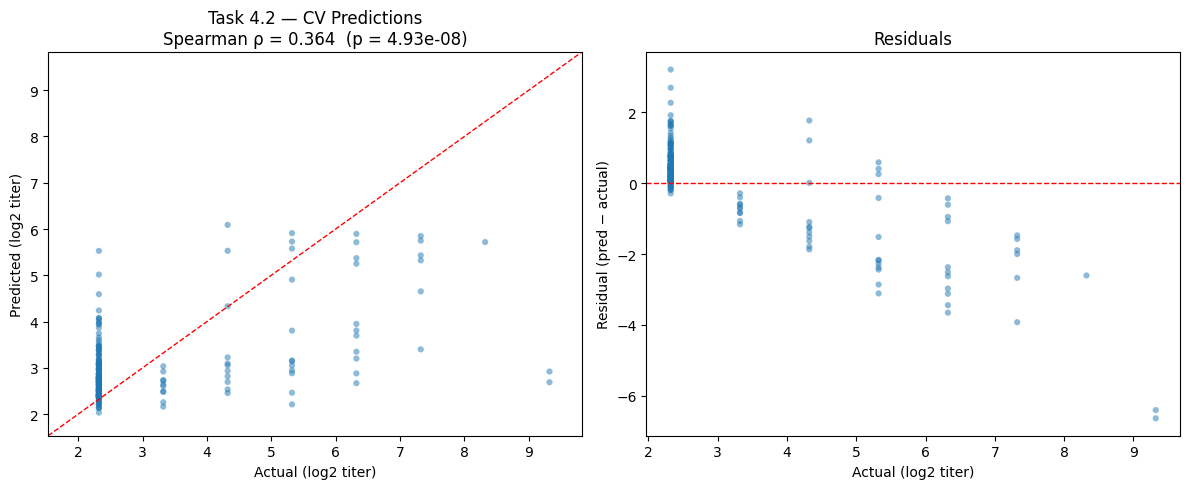

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.scatter(actuals, cv_preds, alpha=0.5, s=20, edgecolors='none')
lim = [min(actuals.min(), cv_preds.min()) - 0.5,
       max(actuals.max(), cv_preds.max()) + 0.5]
ax.plot(lim, lim, 'r--', linewidth=1)
ax.set_xlim(lim)
ax.set_ylim(lim)
ax.set_xlabel('Actual (log2 titer)')
ax.set_ylabel('Predicted (log2 titer)')
ax.set_title(f'Task 4.1 — CV Predictions\nSpearman ρ = {rho:.3f}  (p = {pval:.2e})')

ax = axes[1]
residuals = cv_preds.values - actuals.values
ax.scatter(actuals, residuals, alpha=0.5, s=20, edgecolors='none')
ax.axhline(0, color='r', linestyle='--', linewidth=1)
ax.set_xlabel('Actual (log2 titer)')
ax.set_ylabel('Residual (pred − actual)')
ax.set_title('Residuals')

plt.tight_layout()
plt.show()

Best base model: GBM_2_AutoML_1_20260531_191738


,variable,relative_importance,scaled_importance,percentage
0,HAI_H1N1 A/Victoria/4897/2022_d0,637.088196,1.000000,0.359848
1,HAI_mean_H1N1_d0,261.304932,0.410155,0.147594
2,HAI_mean_all_d0,237.934387,0.373472,0.134393
3,PART_age,120.519455,0.189172,0.068073
4,HAI_mean_H3N2_d0,65.452065,0.102736,0.036969
5,HAI_H3N2 A/Kansas/14/2017_d0,60.680653,0.095247,0.034274
6,HAI_H3N2 A/South Australia/34/2019_d0,40.830193,0.064089,0.023062
7,HAI_Yam B/Phuket/3073/2013_d0,39.467922,0.061950,0.022293
8,HAI_H3N2 A/Singapore/INFIMH-160019/2016_d0,36.837715,0.057822,0.020807
9,HAI_H1N1 A/Brisbane/2/2018_d0,36.616077,0.057474,0.020682


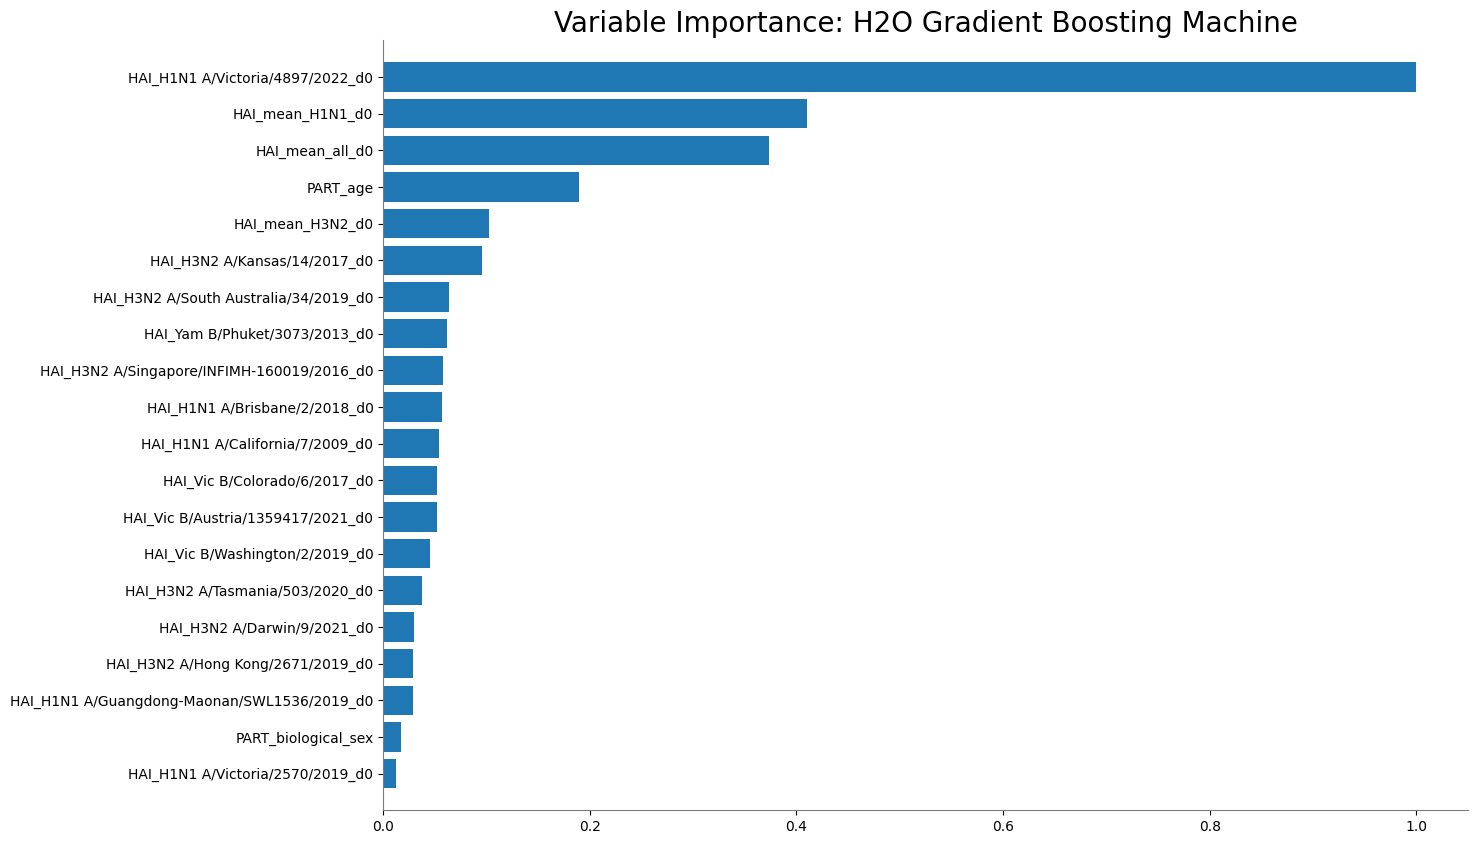

<Figure size 640x480 with 0 Axes>

In [67]:
print(f'Best base model: {top_base_model.model_id}')
varimp = top_base_model.varimp(use_pandas=True)
display(varimp.head(20))
top_base_model.varimp_plot(num_of_features=20)

In [68]:
challenge_col_types = {c: 'real' for c in hai_feature_cols if c in challenge_data.columns}
challenge_col_types.update({c: 'real' for c in surviving_tran if c in challenge_data.columns})
challenge_hf = h2o.H2OFrame(challenge_data, column_types=challenge_col_types)
y_pred = top_model.predict(challenge_hf).as_data_frame(use_multi_thread=True)['predict']

results = pd.DataFrame({
    'Participant_ID': challenge_data['participant_id'].values,
    'Task_4.1': np.exp2(y_pred),
})
results.to_csv(f'{SUBMISSION_PATH}/task_4_1.csv', index=False)
results

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%


c:\Users\arvin\AppData\Local\Programs\Python\Python313\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


,Participant_ID,Task_4.1
0,2024_UGA.ID_077,5.177261
1,2024_UGA.ID_086,17.789868
2,2024_UGA.ID_128,33.665702
3,2024_UGA.ID_170,7.958880
4,2024_UGA.ID_179,7.169659
5,2024_UGA.ID_215,4.534824
6,2024_UGA.ID_219,6.373670
7,2024_UGA.ID_275,13.973848
8,2024_UGA.ID_295,14.402770
9,2024_UGA.ID_296,7.471495


In [69]:
model_path = h2o.save_model(model=top_model, path='.', filename='models/model_4.1', force=True)
print(f'Model saved to: {model_path}')

Model saved to: C:\Users\arvin\DSE260A\cmi-flu-prediction-challenge-capstone\automl_models\models\model_4.1


In [70]:
h2o.cluster().shutdown()

H2O session _sid_b645 closed.


---
## Conclusion

- **Leader model:** TBD (re-run to populate)
- **Scoring model:** TBD (best non-StackedEnsemble base, used for CV Spearman)
- **CV Spearman:** TBD
- **Training samples:** TBD | **Features:** TBD
- **Model saved:** `automl_models/models/model_4.1`

**Target:** log2 HAI titer for H1N1 A/Victoria/4897/2022 at D28. This strain appears only in
specific cohort years so the training set is substantially smaller than other tasks. The pre-vaccination
titer for the same strain (`HAI_H1N1 A/Victoria/4897/2022_d0`) is expected to be the dominant predictor.
Challenge predictions are back-transformed via `np.exp2` to raw titer scale.

**Feature set:** demographics + HAI d0/d7 columns + TRAN PCs, after dropping columns >80% missing
and all d28/d365 leakage columns. `FORCE_KEEP_TRANSCRIPTOMICS = True` preserves all TRAN PCs
regardless of sparsity. All HAI and TRAN columns are explicitly typed `real` on both training and
challenge H2OFrames to prevent auto-type mismatches.

**Imputation note:** No manual imputation. H2O's tree models handle `NaN` natively at each split,
eliminating leakage that would arise from pre-computing medians on the full training set.

Submission saved to `submission/task_4_1.csv`.

To reload the model: `h2o.load_model('automl_models/models/model_4.1')`